# GGSN PAWEŁ RYCERZ ZAD 4
# Grafowe Sieci Neuronowe (GNN) — Dataset CiteSeer
## Klasyfikacja wierzchołków, predykcja krawędzi, analiza anomalii

---

**Autor:** Paweł Rycerz
**Cel:** Zastosowanie modeli GNN do rozwiązywania problemów grafowych na zbiorze **CiteSeer** — sieci cytowań artykułów naukowych.  
**Zadania:**
- Klasyfikacja wierzchołków (node classification) — przewidywanie kategorii artykułu
- Predykcja krawędzi (link prediction) — przewidywanie nowych cytowań
- Detekcja anomalii (anomaly detection) — wykrywanie podejrzanych węzłów

**Modele:**
- GCN — Graph Convolutional Network
- GAT — Graph Attention Network
- GraphSAGE — Graph Sample and Aggregate
- GRNN — Graph Recurrent Neural Network
- GAE — Graph Autoencoder (do predykcji krawędzi i anomalii)

**Regularyzacja:** Dropout, Weight Decay, BatchNorm, Early Stopping  
**Optymalizacja:** Grid Search po hiperparametrach, porównanie optymalizatorów  
**Dane:** CiteSeer — 3327 węzłów, 4732 krawędzi, 6 klas, 3703 cechy

## 1. Instalacja zależności

In [43]:
print("📦 Instaluję PyTorch...")
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

print("📦 Instaluję torch_geometric...")
!pip install torch_geometric

print("📦 Instaluję resztę bibliotek...")
!pip install scikit-learn matplotlib seaborn pandas networkx

print("✅ Wszystkie biblioteki zainstalowane.")

📦 Instaluję PyTorch...
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
📦 Instaluję torch_geometric...
Defaulting to user installation because normal site-packages is not writeable
📦 Instaluję resztę bibliotek...
Defaulting to user installation because normal site-packages is not writeable
✅ Wszystkie biblioteki zainstalowane.


## 2. Importy i konfiguracja

In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import RandomLinkSplit, NormalizeFeatures
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GAE
from torch_geometric.utils import to_networkx, degree
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              average_precision_score, classification_report,
                              ConfusionMatrixDisplay, precision_recall_curve,
                              roc_curve)
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

# Konfiguracja
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Używane urządzenie: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Używane urządzenie: cpu
PyTorch: 2.10.0+cpu


## 3. Zbiór danych CiteSeer

CiteSeer to sieć cytowań artykułów naukowych.  
- **Węzły** = artykuły (3327)  
- **Krawędzie** = cytowania między artykułami (4732)  
- **Cechy** = reprezentacja bag-of-words (3703 cechy binarne)  
- **Klasy** = 6 dziedzin nauki: Agents, AI, DB, HCI, IR, ML

In [45]:
# Wczytanie datasetu CiteSeer z normalizacją cech
dataset = Planetoid(root='data/CiteSeer', name='CiteSeer', transform=NormalizeFeatures())
data    = dataset[0].to(DEVICE)

CLASS_NAMES = ['Agents', 'AI', 'DB', 'HCI', 'IR', 'ML']

print("=" * 50)
print(f"Dataset: {dataset}")
print(f"Liczba grafów:        {len(dataset)}")
print(f"Liczba klas:          {dataset.num_classes}")
print(f"Liczba cech węzłów:   {dataset.num_node_features}")
print("-" * 50)
print(f"Liczba węzłów:        {data.num_nodes}")
print(f"Liczba krawędzi:      {data.num_edges}")
print(f"Średni stopień węzła: {data.num_edges / data.num_nodes:.2f}")
print(f"Graf skierowany:      {data.is_directed()}")
print(f"Izolowane węzły:      {data.has_isolated_nodes()}")
print(f"Pętle własne:         {data.has_self_loops()}")
print("=" * 50)
print(f"\nWęzły treningowe:     {data.train_mask.sum().item()}")
print(f"Węzły walidacyjne:    {data.val_mask.sum().item()}")
print(f"Węzły testowe:        {data.test_mask.sum().item()}")

Dataset: CiteSeer()
Liczba grafów:        1
Liczba klas:          6
Liczba cech węzłów:   3703
--------------------------------------------------
Liczba węzłów:        3327
Liczba krawędzi:      9104
Średni stopień węzła: 2.74
Graf skierowany:      False
Izolowane węzły:      True
Pętle własne:         False

Węzły treningowe:     120
Węzły walidacyjne:    500
Węzły testowe:        1000


## 4. Eksploracyjna analiza danych (EDA)

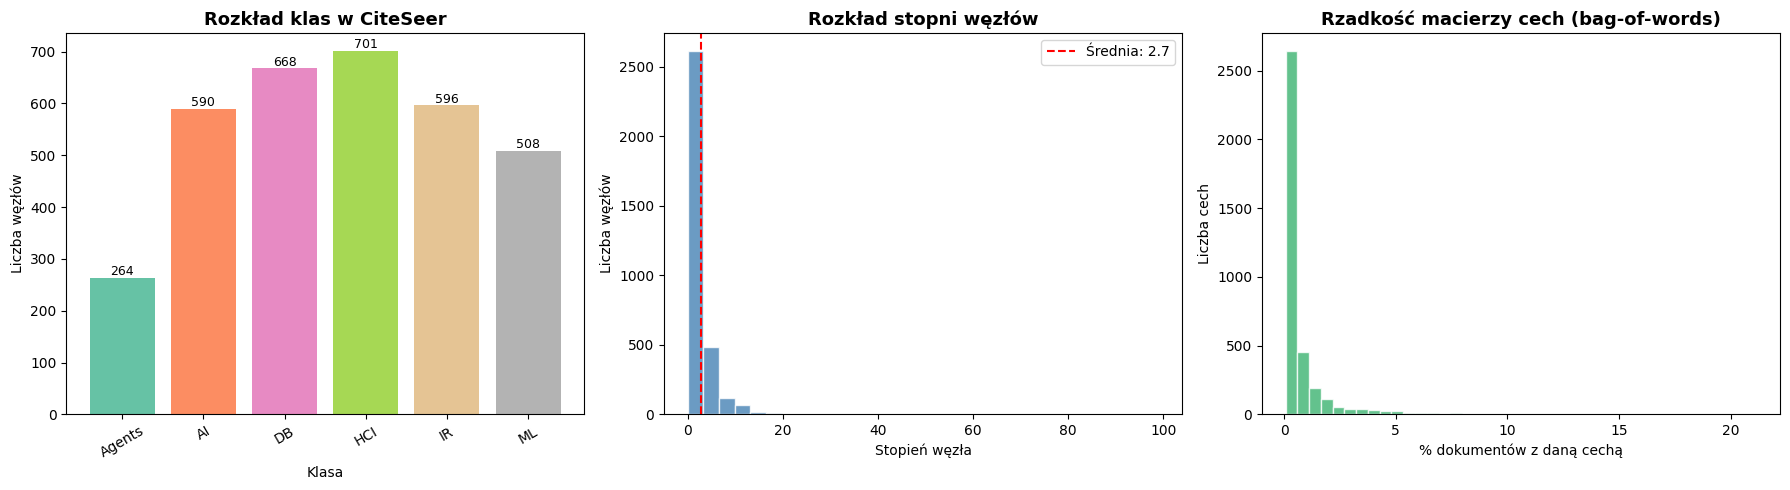

Średni stopień węzła:         2.74
Mediana stopnia:              2.00
Max stopień:                  99
% węzłów z degree=0 (izolowane): 1.4%
Gęstość grafu:                0.0822%


In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rozkład klas
labels = data.y.cpu().numpy()
unique, counts = np.unique(labels, return_counts=True)
axes[0].bar([CLASS_NAMES[i] for i in unique], counts,
            color=plt.cm.Set2(np.linspace(0, 1, len(unique))))
axes[0].set_title('Rozkład klas w CiteSeer', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Liczba węzłów')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# Rozkład stopni węzłów
deg = degree(data.edge_index[0], num_nodes=data.num_nodes).cpu().numpy()
axes[1].hist(deg, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Rozkład stopni węzłów', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Stopień węzła')
axes[1].set_ylabel('Liczba węzłów')
axes[1].axvline(deg.mean(), color='red', linestyle='--', label=f'Średnia: {deg.mean():.1f}')
axes[1].legend()

# Gęstość cech (% niezerowych)
x_np = data.x.cpu().numpy()
nonzero_pct = (x_np != 0).mean(axis=0) * 100
axes[2].hist(nonzero_pct, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[2].set_title('Rzadkość macierzy cech (bag-of-words)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('% dokumentów z daną cechą')
axes[2].set_ylabel('Liczba cech')

plt.tight_layout()
plt.show()

print(f"Średni stopień węzła:         {deg.mean():.2f}")
print(f"Mediana stopnia:              {np.median(deg):.2f}")
print(f"Max stopień:                  {deg.max():.0f}")
print(f"% węzłów z degree=0 (izolowane): {(deg==0).mean()*100:.1f}%")
print(f"Gęstość grafu:                {data.num_edges / (data.num_nodes**2) * 100:.4f}%")

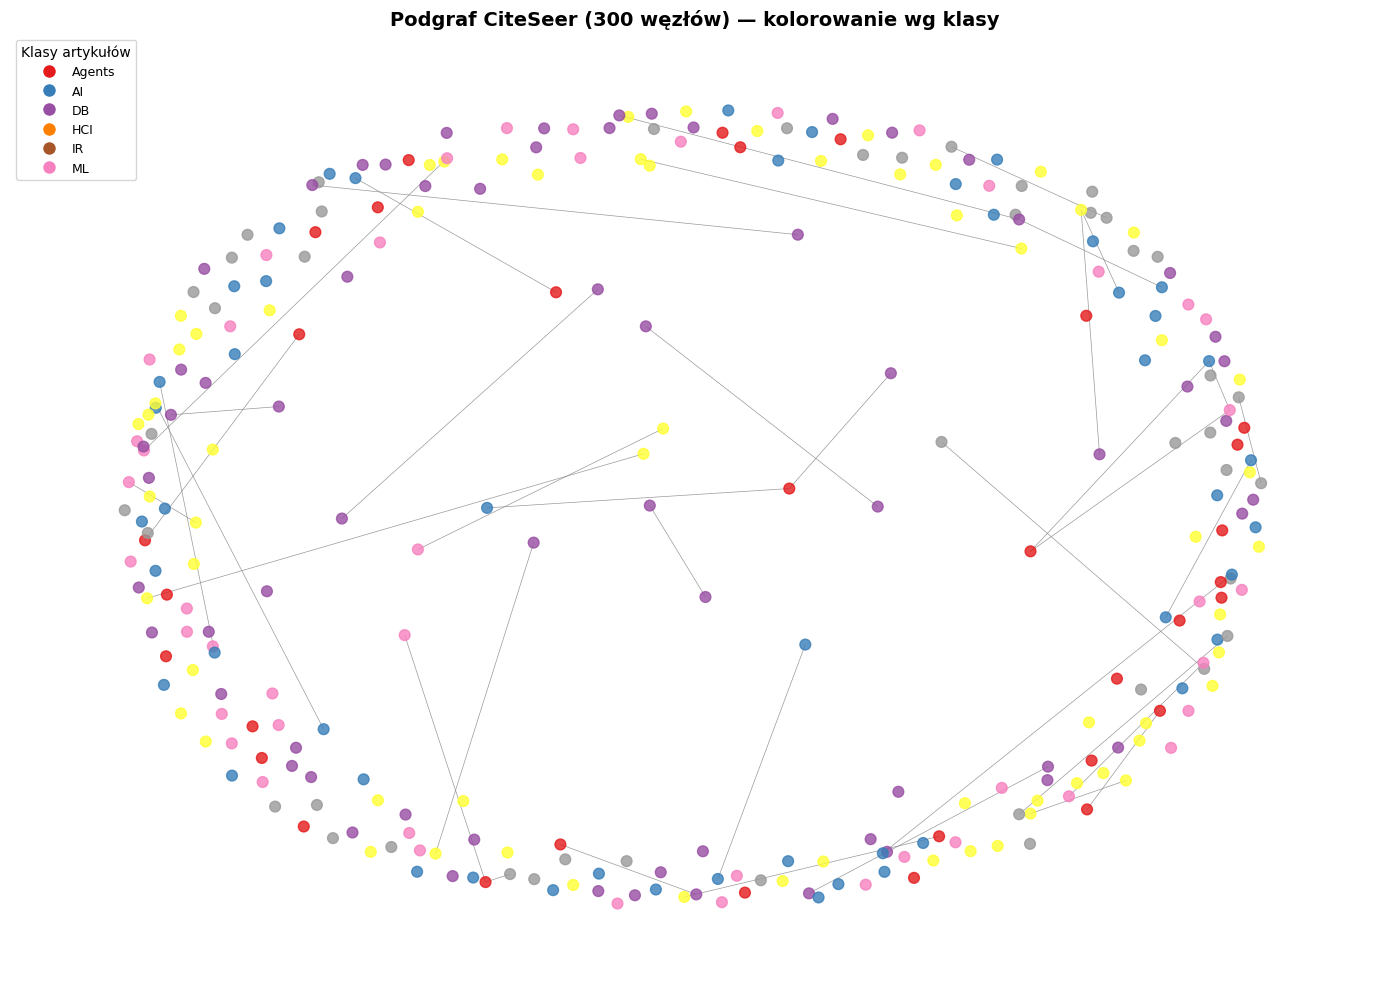

In [47]:
# Wizualizacja podgrafu (pierwsze 300 węzłów)
G = to_networkx(data, to_undirected=True)
G_sub = G.subgraph(range(300))

pos = nx.spring_layout(G_sub, seed=SEED, k=0.5)
node_colors = [labels[i] for i in range(300)]

plt.figure(figsize=(14, 10))
nx.draw_networkx(G_sub, pos=pos,
                 node_color=node_colors,
                 cmap=plt.cm.Set1,
                 node_size=60,
                 with_labels=False,
                 edge_color='gray',
                 alpha=0.8,
                 width=0.5)
# Legenda
handles = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=plt.cm.Set1(i/6.0), markersize=10,
                       label=CLASS_NAMES[i]) for i in range(6)]
plt.legend(handles=handles, title='Klasy artykułów', loc='upper left', fontsize=9)
plt.title('Podgraf CiteSeer (300 węzłów) — kolorowanie wg klasy', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Funkcje pomocnicze

In [48]:
def compute_metrics_node(model, data, mask):
    """Oblicza metryki klasyfikacji węzłów dla zadanej maski."""
    model.eval()
    with torch.no_grad():
        out   = model(data.x, data.edge_index)
        probs = F.softmax(out, dim=1)
        preds = out[mask].argmax(dim=1).cpu().numpy()
        true  = data.y[mask].cpu().numpy()
        probs_np = probs[mask].cpu().numpy()

    acc = accuracy_score(true, preds)
    f1  = f1_score(true, preds, average='weighted', zero_division=0)
    try:
        roc = roc_auc_score(true, probs_np, multi_class='ovr', average='weighted')
    except Exception:
        roc = float('nan')
    return acc, f1, roc, preds, true, probs_np


def train_node_classification(model, data, optimizer, epochs=200,
                               patience=20, verbose=True):
    """Pętla treningowa z early stopping."""
    best_val_loss = float('inf')
    best_weights  = None
    counter       = 0
    history       = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # Walidacja
        model.eval()
        with torch.no_grad():
            out_val  = model(data.x, data.edge_index)
            val_loss = F.nll_loss(out_val[data.val_mask], data.y[data.val_mask]).item()
            val_preds = out_val[data.val_mask].argmax(dim=1)
            val_acc   = (val_preds == data.y[data.val_mask]).float().mean().item()

        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            counter       = 0
        else:
            counter += 1
            if counter >= patience:
                if verbose:
                    print(f"  Early stopping w epoce {epoch}")
                break

        if verbose and epoch % 50 == 0:
            print(f"  Epoka {epoch:4d} | Train Loss: {loss.item():.4f} "
                  f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if best_weights:
        model.load_state_dict(best_weights)
    return history


def plot_training_history(histories, model_names, title='Krzywe uczenia'):
    """Rysuje training/validation loss dla wielu modeli."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))

    for hist, name, c in zip(histories, model_names, colors):
        axes[0].plot(hist['train_loss'], label=f'{name}', color=c, linewidth=1.5)
        axes[1].plot(hist['val_loss'],   label=f'{name}', color=c, linewidth=1.5)

    axes[0].set_title('Strata treningowa', fontweight='bold')
    axes[1].set_title('Strata walidacyjna', fontweight='bold')
    for ax in axes:
        ax.set_xlabel('Epoka')
        ax.set_ylabel('Strata (NLL)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_embeddings_tsne(model, data, title, layer_output_fn=None):
    """Wizualizacja embeddingów modelu za pomocą t-SNE."""
    model.eval()
    with torch.no_grad():
        if layer_output_fn:
            z = layer_output_fn(model, data).cpu().numpy()
        else:
            out = model(data.x, data.edge_index)
            z   = F.softmax(out, dim=1).cpu().numpy()

    z_2d   = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(z)
    colors = data.y.cpu().numpy()

    plt.figure(figsize=(9, 7))
    scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=colors, cmap='Set1',
                          s=15, alpha=0.75)
    handles = [plt.Line2D([0],[0], marker='o', color='w',
                           markerfacecolor=plt.cm.Set1(i/6.0),
                           markersize=8, label=CLASS_NAMES[i]) for i in range(6)]
    plt.legend(handles=handles, title='Klasa', fontsize=9)
    plt.title(f't-SNE embeddingów — {title}', fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    
    plt.show()

print("✅ Funkcje pomocnicze zdefiniowane.")

✅ Funkcje pomocnicze zdefiniowane.


## 6. Definicje modeli GNN

### 6.1 GCN — Graph Convolutional Network

GCN (Kipf & Welling, 2017) agreguje cechy sąsiadów poprzez znormalizowane mnożenie macierzowe.  
Propagacja: $H^{(l+1)} = \sigma\left(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}H^{(l)}W^{(l)}\right)$

In [49]:
class GCN(nn.Module):
    """
    Graph Convolutional Network — wielowarstwowy.
    Parametry:
        in_channels   : wymiar cech wejściowych
        hidden_dim    : rozmiar warstwy ukrytej
        out_channels  : liczba klas
        num_layers    : całkowita liczba warstw konwolucyjnych
        dropout       : współczynnik dropout
    """
    def __init__(self, in_channels, hidden_dim, out_channels,
                 num_layers=2, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.convs   = nn.ModuleList()
        self.bns     = nn.ModuleList()

        # Pierwsza warstwa
        self.convs.append(GCNConv(in_channels, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Warstwy ukryte
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        # Ostatnia warstwa
        self.convs.append(GCNConv(hidden_dim, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

    def get_embedding(self, x, edge_index):
        """Zwraca embedding z przedostatniej warstwy."""
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
        return x

print("✅ GCN zdefiniowany.")

✅ GCN zdefiniowany.


### 6.2 GAT — Graph Attention Network

GAT (Veličković et al., 2018) używa mechanizmu uwagi do przypisywania różnych wag sąsiadom.  
Uwaga: $\alpha_{ij} = \text{softmax}(\text{LeakyReLU}(\mathbf{a}^T[W\mathbf{h}_i \| W\mathbf{h}_j]))$

In [50]:
class GAT(nn.Module):
    """
    Graph Attention Network z wieloma głowicami uwagi.
    Parametry:
        in_channels  : wymiar cech wejściowych
        hidden_dim   : rozmiar ukrytej reprezentacji na głowicę
        out_channels : liczba klas
        heads        : liczba głowic uwagi w 1. warstwie
        dropout      : współczynnik dropout
    """
    def __init__(self, in_channels, hidden_dim, out_channels,
                 heads=8, dropout=0.6):
        super().__init__()
        self.dropout = dropout
        self.conv1   = GATConv(in_channels, hidden_dim,
                               heads=heads, dropout=dropout, concat=True)
        self.conv2   = GATConv(hidden_dim * heads, out_channels,
                               heads=1, dropout=dropout, concat=False)
        self.bn1     = nn.BatchNorm1d(hidden_dim * heads)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

    def get_embedding(self, x, edge_index):
        x = F.dropout(x, p=0.0)
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        return F.elu(x)

print("✅ GAT zdefiniowany.")

✅ GAT zdefiniowany.


### 6.3 GraphSAGE — Graph Sample and Aggregate

GraphSAGE (Hamilton et al., 2017) próbkuje sąsiadów i agreguje ich cechy (mean/max/LSTM).  
Agregacja: $\mathbf{h}_v^{(l)} = \sigma\left(W \cdot \text{CONCAT}\left(\mathbf{h}_v^{(l-1)}, \text{AGG}(\{\mathbf{h}_u^{(l-1)}, u \in \mathcal{N}(v)\})\right)\right)$

In [51]:
class GraphSAGE(nn.Module):
    """
    GraphSAGE z agregacją 'mean'.
    Parametry:
        in_channels  : wymiar cech wejściowych
        hidden_dim   : rozmiar warstwy ukrytej
        out_channels : liczba klas
        num_layers   : liczba warstw SAGE
        dropout      : współczynnik dropout
    """
    def __init__(self, in_channels, hidden_dim, out_channels,
                 num_layers=2, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.convs   = nn.ModuleList()
        self.bns     = nn.ModuleList()

        self.convs.append(SAGEConv(in_channels, hidden_dim))
        self.bns.append(nn.BatchNorm1d(hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.convs.append(SAGEConv(hidden_dim, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

    def get_embedding(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
        return x

print("✅ GraphSAGE zdefiniowany.")

✅ GraphSAGE zdefiniowany.


### 6.4 GRNN — Graph Recurrent Neural Network

GRNN iteracyjnie aktualizuje stan węzłów poprzez agregację stanów sąsiadów, imitując komórkę RNN na grafie.

In [52]:
class GRNNCell(nn.Module):
    """Komórka GRU-podobna dla grafów."""
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        # Bramka resetu
        self.W_r  = nn.Linear(in_channels + hidden_channels, hidden_channels)
        # Bramka aktualizacji
        self.W_z  = nn.Linear(in_channels + hidden_channels, hidden_channels)
        # Nowy stan kandydujący
        self.W_h  = nn.Linear(in_channels + hidden_channels, hidden_channels)

    def forward(self, x, h_neigh):
        combined = torch.cat([x, h_neigh], dim=-1)
        r = torch.sigmoid(self.W_r(combined))
        z = torch.sigmoid(self.W_z(combined))
        combined_r = torch.cat([x, r * h_neigh], dim=-1)
        h_tilde = torch.tanh(self.W_h(combined_r))
        h_new = (1 - z) * h_neigh + z * h_tilde
        return h_new


class GRNN(nn.Module):
    """
    Graph Recurrent Neural Network.
    Parametry:
        in_channels    : wymiar cech wejściowych
        hidden_channels: rozmiar stanu ukrytego
        out_channels   : liczba klas
        num_iters      : liczba kroków propagacji
        dropout        : współczynnik dropout
    """
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_iters=3, dropout=0.5):
        super().__init__()
        self.num_iters  = num_iters
        self.dropout    = dropout
        self.input_proj = nn.Linear(in_channels, hidden_channels)
        self.cell       = GRNNCell(hidden_channels, hidden_channels)
        self.bn         = nn.BatchNorm1d(hidden_channels)
        self.out        = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.input_proj(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        h = x.clone()

        src, dst = edge_index
        for _ in range(self.num_iters):
            # Wektorowa agregacja sąsiadów (efektywna)
            h_neigh = torch.zeros_like(h)
            count   = torch.zeros(h.size(0), 1, device=h.device)
            h_neigh.index_add_(0, dst, h[src])
            count.index_add_(0, dst, torch.ones(src.size(0), 1, device=h.device))
            count = count.clamp(min=1)
            h_neigh = h_neigh / count
            h = self.cell(x, h_neigh)

        h = self.bn(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        return F.log_softmax(self.out(h), dim=1)

    def get_embedding(self, x, edge_index):
        x = F.relu(self.input_proj(x))
        h = x.clone()
        src, dst = edge_index
        for _ in range(self.num_iters):
            h_neigh = torch.zeros_like(h)
            count   = torch.zeros(h.size(0), 1, device=h.device)
            h_neigh.index_add_(0, dst, h[src])
            count.index_add_(0, dst, torch.ones(src.size(0), 1, device=h.device))
            count  = count.clamp(min=1)
            h_neigh = h_neigh / count
            h = self.cell(x, h_neigh)
        return self.bn(h)

print("✅ GRNN zdefiniowany.")

✅ GRNN zdefiniowany.


## 7. Klasyfikacja wierzchołków

Trenujemy każdy model na zbiorze treningowym (120 węzłów — 20 na klasę),  
walidujemy na 500 węzłach, testujemy na 1000 węzłach.

In [53]:
# ── Konfiguracja modeli (baseline) ──────────────────────────────────────────
IN_CH = dataset.num_node_features
OUT_CH = dataset.num_classes

models_config = {
    'GCN':       GCN(IN_CH, hidden_dim=64,  out_channels=OUT_CH, num_layers=2, dropout=0.5),
    'GAT':       GAT(IN_CH, hidden_dim=8,   out_channels=OUT_CH, heads=8, dropout=0.6),
    'GraphSAGE': GraphSAGE(IN_CH, hidden_dim=64, out_channels=OUT_CH, num_layers=2, dropout=0.5),
    'GRNN':      GRNN(IN_CH, hidden_channels=64, out_channels=OUT_CH, num_iters=3, dropout=0.5),
}

histories    = {}
test_results = {}

for name, model in models_config.items():
    print(f"\n{'='*55}")
    print(f"  Trenowanie: {name}")
    print(f"{'='*55}")
    model = model.to(DEVICE)
    lr_map = {'GCN': 0.01, 'GAT': 0.005, 'GraphSAGE': 0.01, 'GRNN': 0.005}
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr_map[name], weight_decay=5e-4)

    hist = train_node_classification(model, data, optimizer,
                                     epochs=300, patience=30, verbose=True)
    histories[name] = hist

    # Ewaluacja na zbiorze testowym
    acc, f1, roc, preds, true, probs = compute_metrics_node(model, data, data.test_mask)
    test_results[name] = {'acc': acc, 'f1': f1, 'roc': roc,
                           'preds': preds, 'true': true, 'probs': probs, 'model': model}
    print(f"  TEST → Acc: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f}")


  Trenowanie: GCN
  Epoka   50 | Train Loss: 0.0032 | Val Loss: 1.3455 | Val Acc: 0.7040
  Epoka  100 | Train Loss: 0.0030 | Val Loss: 1.0912 | Val Acc: 0.6780
  Early stopping w epoce 114
  TEST → Acc: 0.6660 | F1: 0.6725 | ROC-AUC: 0.8840

  Trenowanie: GAT
  Epoka   50 | Train Loss: 0.5519 | Val Loss: 1.4453 | Val Acc: 0.6400
  Epoka  100 | Train Loss: 0.4817 | Val Loss: 1.0617 | Val Acc: 0.6600
  Early stopping w epoce 114
  TEST → Acc: 0.6700 | F1: 0.6728 | ROC-AUC: 0.8877

  Trenowanie: GraphSAGE
  Epoka   50 | Train Loss: 0.0006 | Val Loss: 1.3185 | Val Acc: 0.6380
  Epoka  100 | Train Loss: 0.0010 | Val Loss: 1.0902 | Val Acc: 0.6520
  Early stopping w epoce 133
  TEST → Acc: 0.6550 | F1: 0.6614 | ROC-AUC: 0.8877

  Trenowanie: GRNN
  Epoka   50 | Train Loss: 0.0168 | Val Loss: 1.4509 | Val Acc: 0.6280
  Epoka  100 | Train Loss: 0.0026 | Val Loss: 1.2568 | Val Acc: 0.5940
  Early stopping w epoce 111
  TEST → Acc: 0.6540 | F1: 0.6627 | ROC-AUC: 0.8874


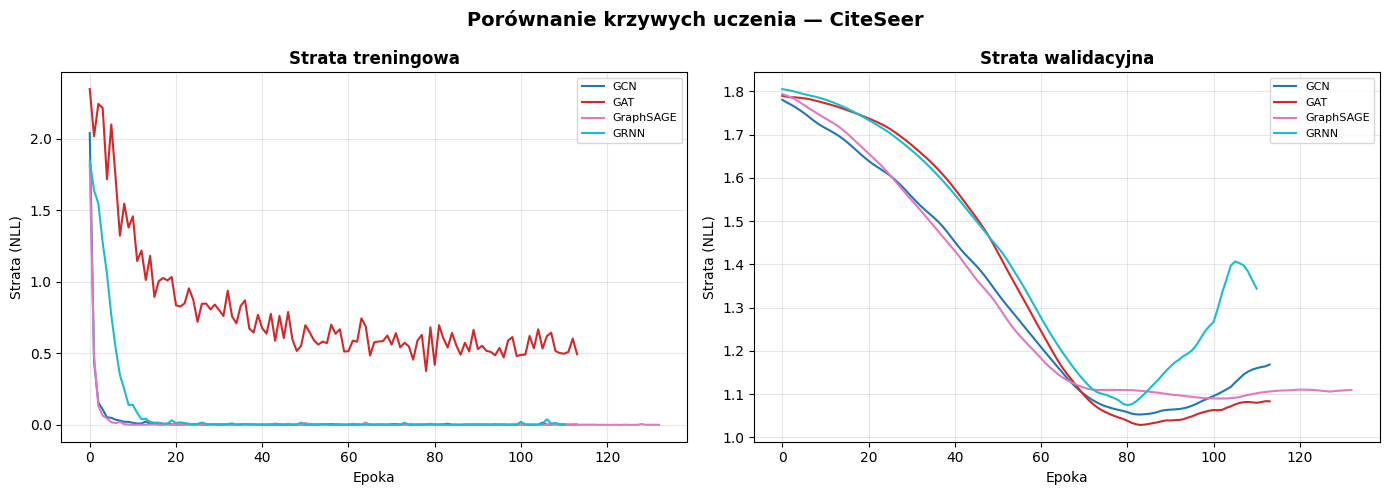

In [54]:
# Porównanie krzywych uczenia
plot_training_history(list(histories.values()), list(histories.keys()),
                      title='Porównanie krzywych uczenia — CiteSeer')


📊 WYNIKI NA ZBIORZE TESTOWYM — BASELINE
           Accuracy  F1-Score (weighted)  ROC-AUC
GCN           0.666               0.6725   0.8840
GAT           0.670               0.6728   0.8877
GraphSAGE     0.655               0.6614   0.8877
GRNN          0.654               0.6627   0.8874



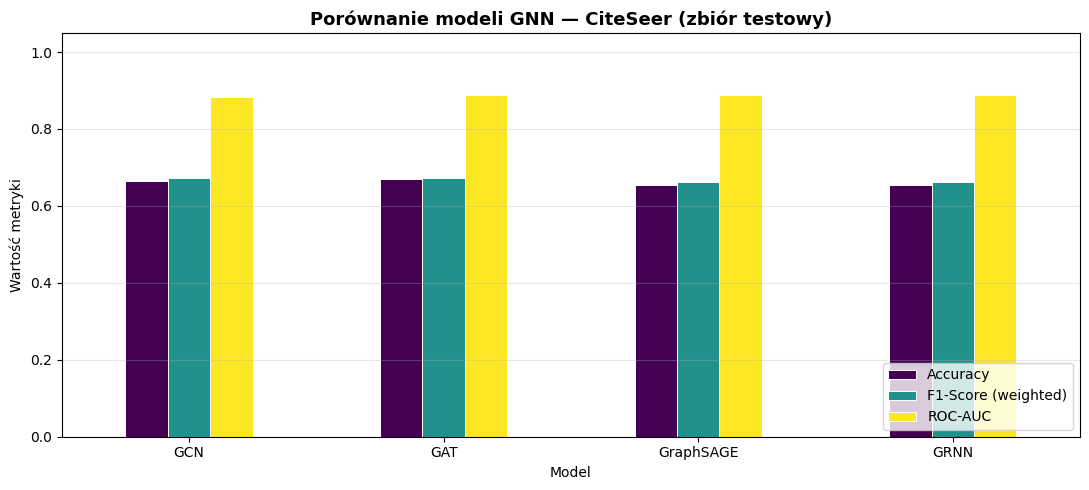

In [55]:
# ── Tabela wyników ──────────────────────────────────────────────────────────
df_baseline = pd.DataFrame({
    name: {'Accuracy': v['acc'], 'F1-Score (weighted)': v['f1'], 'ROC-AUC': v['roc']}
    for name, v in test_results.items()
}).T.round(4)

print("\n📊 WYNIKI NA ZBIORZE TESTOWYM — BASELINE")
print("=" * 55)
print(df_baseline.to_string())
print()

# Wykres słupkowy
df_baseline.plot(kind='bar', figsize=(11, 5), colormap='viridis',
                 edgecolor='white', linewidth=0.7)
plt.title('Porównanie modeli GNN — CiteSeer (zbiór testowy)', fontsize=13, fontweight='bold')
plt.ylabel('Wartość metryki')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

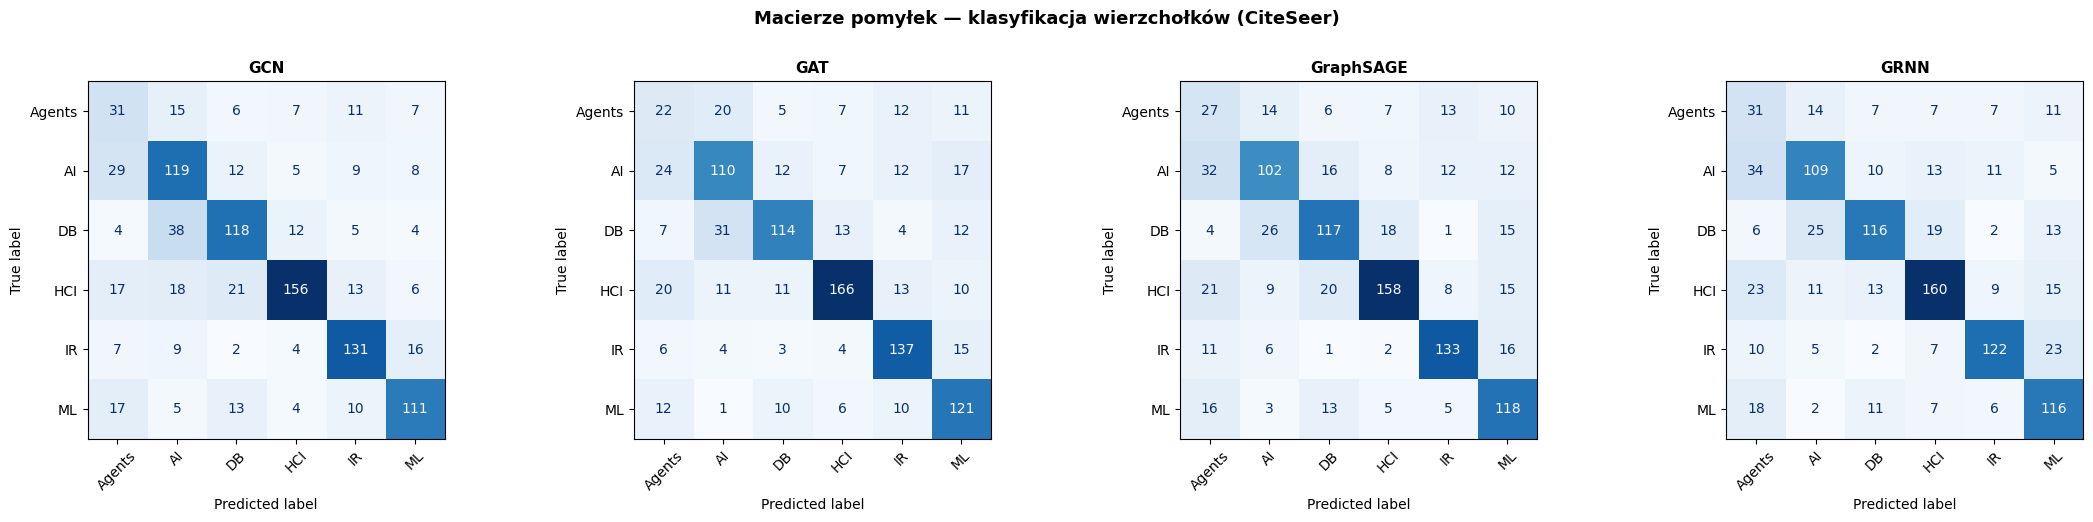

In [56]:
# ── Macierze pomyłek ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, res) in zip(axes, test_results.items()):
    ConfusionMatrixDisplay.from_predictions(
        res['true'], res['preds'],
        display_labels=CLASS_NAMES,
        ax=ax, colorbar=False, cmap='Blues',
        xticks_rotation=45
    )
    ax.set_title(f'{name}', fontsize=11, fontweight='bold')

plt.suptitle('Macierze pomyłek — klasyfikacja wierzchołków (CiteSeer)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [57]:
# ── Szczegółowe raporty klasyfikacji ────────────────────────────────────────
for name, res in test_results.items():
    print(f"\n{'='*55}")
    print(f"  {name} — Classification Report")
    print('='*55)
    print(classification_report(res['true'], res['preds'],
                                 target_names=CLASS_NAMES, zero_division=0))


  GCN — Classification Report
              precision    recall  f1-score   support

      Agents       0.30      0.40      0.34        77
          AI       0.58      0.65      0.62       182
          DB       0.69      0.65      0.67       181
         HCI       0.83      0.68      0.74       231
          IR       0.73      0.78      0.75       169
          ML       0.73      0.69      0.71       160

    accuracy                           0.67      1000
   macro avg       0.64      0.64      0.64      1000
weighted avg       0.69      0.67      0.67      1000


  GAT — Classification Report
              precision    recall  f1-score   support

      Agents       0.24      0.29      0.26        77
          AI       0.62      0.60      0.61       182
          DB       0.74      0.63      0.68       181
         HCI       0.82      0.72      0.76       231
          IR       0.73      0.81      0.77       169
          ML       0.65      0.76      0.70       160

    accuracy   

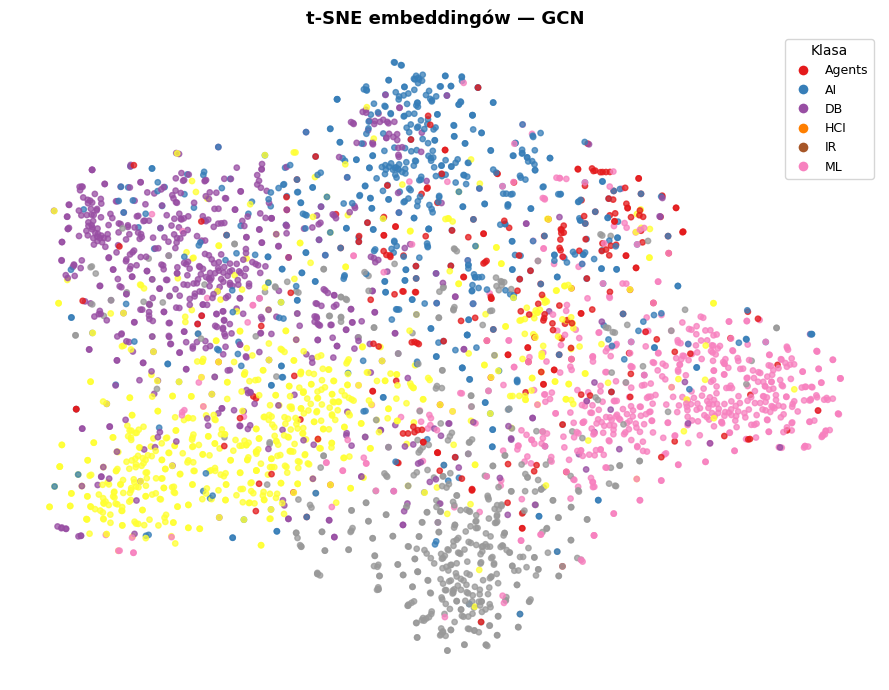

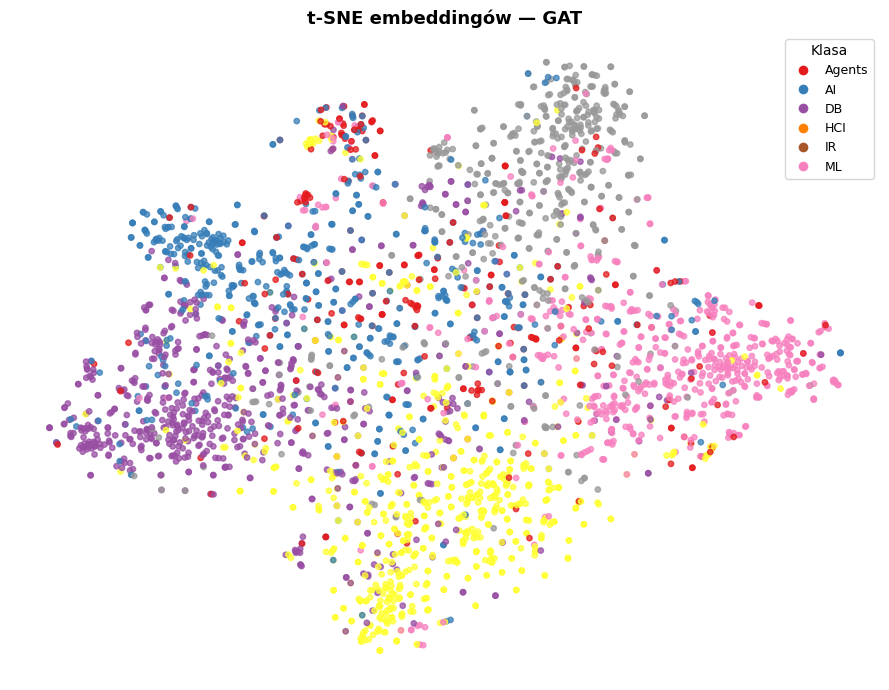

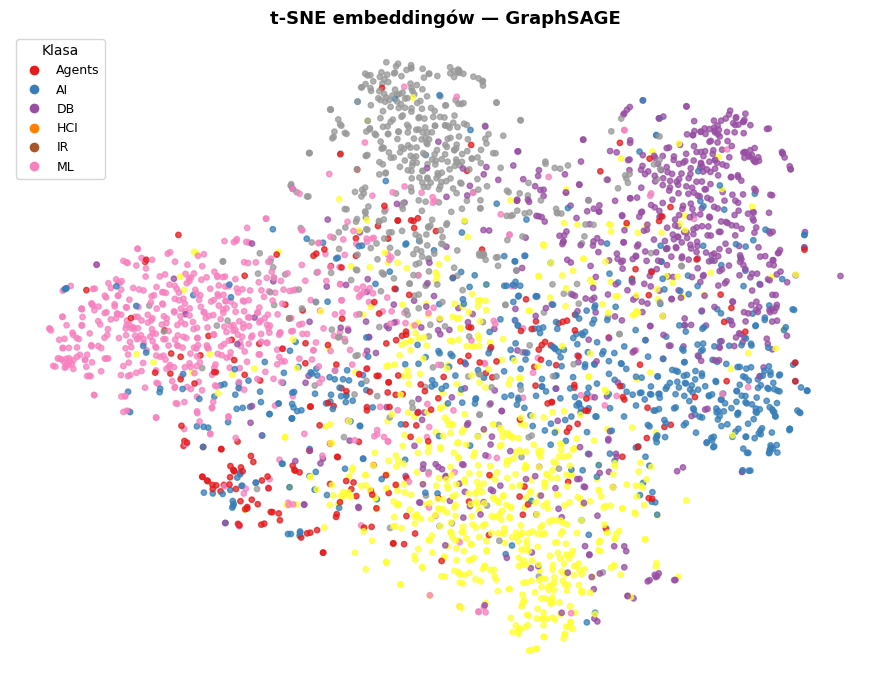

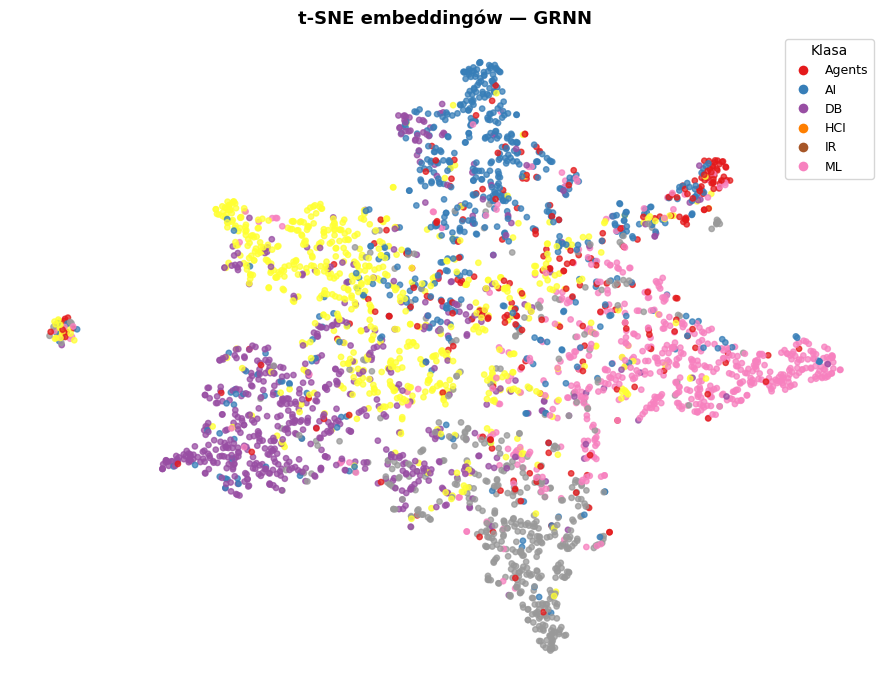

In [58]:
# ── Wizualizacja embeddingów t-SNE ──────────────────────────────────────────
for name, res in test_results.items():
    plot_embeddings_tsne(
        res['model'], data, name,
        layer_output_fn=lambda m, d: m.get_embedding(d.x, d.edge_index)
            if hasattr(m, 'get_embedding') else None
    )

## 8. Strojenie hiperparametrów (Grid Search)

Przeszukujemy siatkę hiperparametrów dla każdego modelu i wybieramy najlepszą konfigurację.

In [59]:
print("🔍 Grid Search — GCN")
print("="*55)

gcn_grid = {
    'hidden_dim': [32, 64, 128],
    'num_layers': [2, 3],
    'dropout':    [0.3, 0.5, 0.7],
    'lr':         [0.01, 0.005, 0.001],
    'weight_decay': [5e-4, 1e-3],
}

gcn_results  = []
best_gcn_val = -float('inf')
best_gcn_cfg = None
best_gcn_mdl = None

for params in ParameterGrid(gcn_grid):
    model = GCN(IN_CH, params['hidden_dim'], OUT_CH,
                params['num_layers'], params['dropout']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=params['lr'],
                                 weight_decay=params['weight_decay'])
    # Krótki trening (50 epok)
    model.train()
    for epoch in range(60):
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    acc, f1, roc, _, _, _ = compute_metrics_node(model, data, data.val_mask)
    gcn_results.append({**params, 'val_acc': acc, 'val_f1': f1, 'val_roc': roc})

    if roc > best_gcn_val:
        best_gcn_val = roc
        best_gcn_cfg = params
        best_gcn_mdl = model

print(f"\n✅ Najlepsza konfiguracja GCN:")
for k, v in best_gcn_cfg.items():
    print(f"   {k}: {v}")
print(f"   Val ROC-AUC: {best_gcn_val:.4f}")

🔍 Grid Search — GCN

✅ Najlepsza konfiguracja GCN:
   dropout: 0.5
   hidden_dim: 128
   lr: 0.005
   num_layers: 2
   weight_decay: 0.001
   Val ROC-AUC: 0.9014


In [60]:
print("\n🔍 Grid Search — GAT")
print("="*55)

gat_grid = {
    'hidden_dim': [8, 16, 32],
    'heads':      [4, 8],
    'dropout':    [0.4, 0.6],
    'lr':         [0.005, 0.001],
    'weight_decay': [5e-4, 1e-3],
}

gat_results  = []
best_gat_val = -float('inf')
best_gat_cfg = None
best_gat_mdl = None

for params in ParameterGrid(gat_grid):
    model = GAT(IN_CH, params['hidden_dim'], OUT_CH,
                params['heads'], params['dropout']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=params['lr'],
                                 weight_decay=params['weight_decay'])
    model.train()
    for epoch in range(60):
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    acc, f1, roc, _, _, _ = compute_metrics_node(model, data, data.val_mask)
    gat_results.append({**params, 'val_acc': acc, 'val_f1': f1, 'val_roc': roc})

    if roc > best_gat_val:
        best_gat_val = roc
        best_gat_cfg = params
        best_gat_mdl = model

print(f"\n✅ Najlepsza konfiguracja GAT:")
for k, v in best_gat_cfg.items():
    print(f"   {k}: {v}")
print(f"   Val ROC-AUC: {best_gat_val:.4f}")


🔍 Grid Search — GAT

✅ Najlepsza konfiguracja GAT:
   dropout: 0.6
   heads: 8
   hidden_dim: 8
   lr: 0.005
   weight_decay: 0.001
   Val ROC-AUC: 0.8999


In [61]:
print("\n🔍 Grid Search — GraphSAGE")
print("="*55)

sage_grid = {
    'hidden_dim': [32, 64, 128],
    'num_layers': [2, 3],
    'dropout':    [0.3, 0.5],
    'lr':         [0.01, 0.005],
    'weight_decay': [5e-4, 1e-3],
}

sage_results  = []
best_sage_val = -float('inf')
best_sage_cfg = None
best_sage_mdl = None

for params in ParameterGrid(sage_grid):
    model = GraphSAGE(IN_CH, params['hidden_dim'], OUT_CH,
                      params['num_layers'], params['dropout']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=params['lr'],
                                 weight_decay=params['weight_decay'])
    model.train()
    for epoch in range(60):
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    acc, f1, roc, _, _, _ = compute_metrics_node(model, data, data.val_mask)
    sage_results.append({**params, 'val_acc': acc, 'val_f1': f1, 'val_roc': roc})

    if roc > best_sage_val:
        best_sage_val = roc
        best_sage_cfg = params
        best_sage_mdl = model

print(f"\n✅ Najlepsza konfiguracja GraphSAGE:")
for k, v in best_sage_cfg.items():
    print(f"   {k}: {v}")
print(f"   Val ROC-AUC: {best_sage_val:.4f}")


🔍 Grid Search — GraphSAGE

✅ Najlepsza konfiguracja GraphSAGE:
   dropout: 0.5
   hidden_dim: 128
   lr: 0.01
   num_layers: 2
   weight_decay: 0.0005
   Val ROC-AUC: 0.8961


In [62]:
print("\n🔍 Grid Search — GRNN")
print("="*55)

grnn_grid = {
    'hidden_channels': [32, 64, 128],
    'num_iters':       [2, 3, 4],
    'dropout':         [0.3, 0.5],
    'lr':              [0.005, 0.001],
    'weight_decay':    [5e-4, 1e-3],
}

grnn_results  = []
best_grnn_val = -float('inf')
best_grnn_cfg = None
best_grnn_mdl = None

for params in ParameterGrid(grnn_grid):
    model = GRNN(IN_CH, params['hidden_channels'], OUT_CH,
                 params['num_iters'], params['dropout']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=params['lr'],
                                 weight_decay=params['weight_decay'])
    model.train()
    for epoch in range(60):
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    acc, f1, roc, _, _, _ = compute_metrics_node(model, data, data.val_mask)
    grnn_results.append({**params, 'val_acc': acc, 'val_f1': f1, 'val_roc': roc})

    if roc > best_grnn_val:
        best_grnn_val = roc
        best_grnn_cfg = params
        best_grnn_mdl = model

print(f"\n✅ Najlepsza konfiguracja GRNN:")
for k, v in best_grnn_cfg.items():
    print(f"   {k}: {v}")
print(f"   Val ROC-AUC: {best_grnn_val:.4f}")


🔍 Grid Search — GRNN

✅ Najlepsza konfiguracja GRNN:
   dropout: 0.3
   hidden_channels: 128
   lr: 0.005
   num_iters: 2
   weight_decay: 0.0005
   Val ROC-AUC: 0.8969


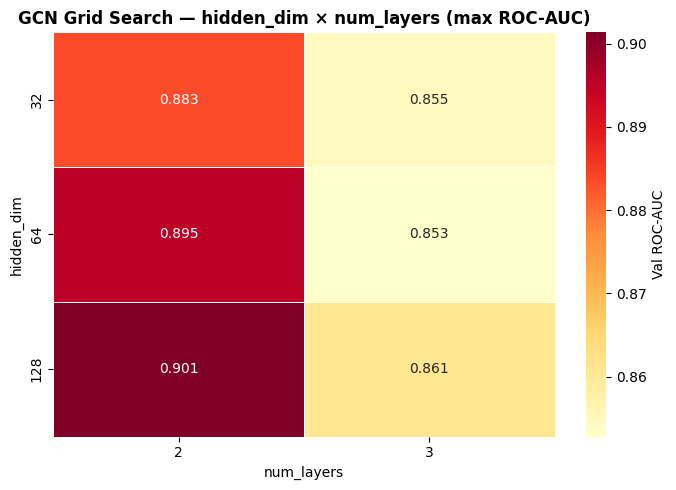

In [63]:
# ── Porównanie heatmap hiperparametrów GCN ──────────────────────────────────
df_gcn_gs = pd.DataFrame(gcn_results)

# Pivot: hidden_dim vs num_layers, wartość = val_roc (uśredniona po pozostałych)
pivot = df_gcn_gs.groupby(['hidden_dim', 'num_layers'])['val_roc'].max().reset_index()
pivot_table = pivot.pivot(index='hidden_dim', columns='num_layers', values='val_roc')

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_table, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Val ROC-AUC'})
plt.title('GCN Grid Search — hidden_dim × num_layers (max ROC-AUC)', fontweight='bold')
plt.tight_layout()
plt.show()

In [64]:
# ── Retrenowanie najlepszych modeli (pełne 300 epok) ────────────────────────
print("🏋️ Retrenowanie najlepszych konfiguracji (300 epok, early stopping)\n")

best_models = {
    'GCN':       (GCN(IN_CH, **{k: v for k, v in best_gcn_cfg.items()
                                if k not in ['lr', 'weight_decay']},
                      out_channels=OUT_CH), best_gcn_cfg),
    'GAT':       (GAT(IN_CH, **{k: v for k, v in best_gat_cfg.items()
                                if k not in ['lr', 'weight_decay']},
                      out_channels=OUT_CH), best_gat_cfg),
    'GraphSAGE': (GraphSAGE(IN_CH, **{k: v for k, v in best_sage_cfg.items()
                                      if k not in ['lr', 'weight_decay']},
                             out_channels=OUT_CH), best_sage_cfg),
    'GRNN':      (GRNN(IN_CH, **{k: v for k, v in best_grnn_cfg.items()
                                 if k not in ['lr', 'weight_decay']},
                       out_channels=OUT_CH), best_grnn_cfg),
}

tuned_results = {}
tuned_histories = {}

for name, (model, cfg) in best_models.items():
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg['lr'],
                                 weight_decay=cfg['weight_decay'])
    hist = train_node_classification(model, data, optimizer,
                                     epochs=300, patience=40, verbose=True)
    tuned_histories[name] = hist
    acc, f1, roc, preds, true, probs = compute_metrics_node(model, data, data.test_mask)
    tuned_results[name] = {'acc': acc, 'f1': f1, 'roc': roc,
                            'preds': preds, 'true': true, 'probs': probs}
    print(f"  {name} TEST → Acc: {acc:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f}")

🏋️ Retrenowanie najlepszych konfiguracji (300 epok, early stopping)

  Epoka   50 | Train Loss: 0.0045 | Val Loss: 1.5263 | Val Acc: 0.6680
  Epoka  100 | Train Loss: 0.0039 | Val Loss: 1.0899 | Val Acc: 0.6500
  Early stopping w epoce 140
  GCN TEST → Acc: 0.6690 | F1: 0.6748 | ROC-AUC: 0.8822
  Epoka   50 | Train Loss: 0.7695 | Val Loss: 1.4553 | Val Acc: 0.6940
  Epoka  100 | Train Loss: 0.5469 | Val Loss: 1.0244 | Val Acc: 0.6720
  Early stopping w epoce 129
  GAT TEST → Acc: 0.6790 | F1: 0.6825 | ROC-AUC: 0.8917
  Epoka   50 | Train Loss: 0.0020 | Val Loss: 1.3211 | Val Acc: 0.6460
  Epoka  100 | Train Loss: 0.0018 | Val Loss: 1.0360 | Val Acc: 0.6780
  Early stopping w epoce 147
  GraphSAGE TEST → Acc: 0.6710 | F1: 0.6772 | ROC-AUC: 0.8975
  Epoka   50 | Train Loss: 0.0008 | Val Loss: 1.3919 | Val Acc: 0.6360
  Epoka  100 | Train Loss: 0.0008 | Val Loss: 1.0669 | Val Acc: 0.6420
  Early stopping w epoce 126
  GRNN TEST → Acc: 0.6640 | F1: 0.6666 | ROC-AUC: 0.9039


📊 BASELINE vs TUNED — ZBIÓR TESTOWY
           Acc (baseline)  F1 (baseline)  AUC (baseline)  Acc (tuned)  F1 (tuned)  AUC (tuned)
Model                                                                                         
GCN                 0.666         0.6725          0.8840        0.669      0.6748       0.8822
GAT                 0.670         0.6728          0.8877        0.679      0.6825       0.8917
GraphSAGE           0.655         0.6614          0.8877        0.671      0.6772       0.8975
GRNN                0.654         0.6627          0.8874        0.664      0.6666       0.9039


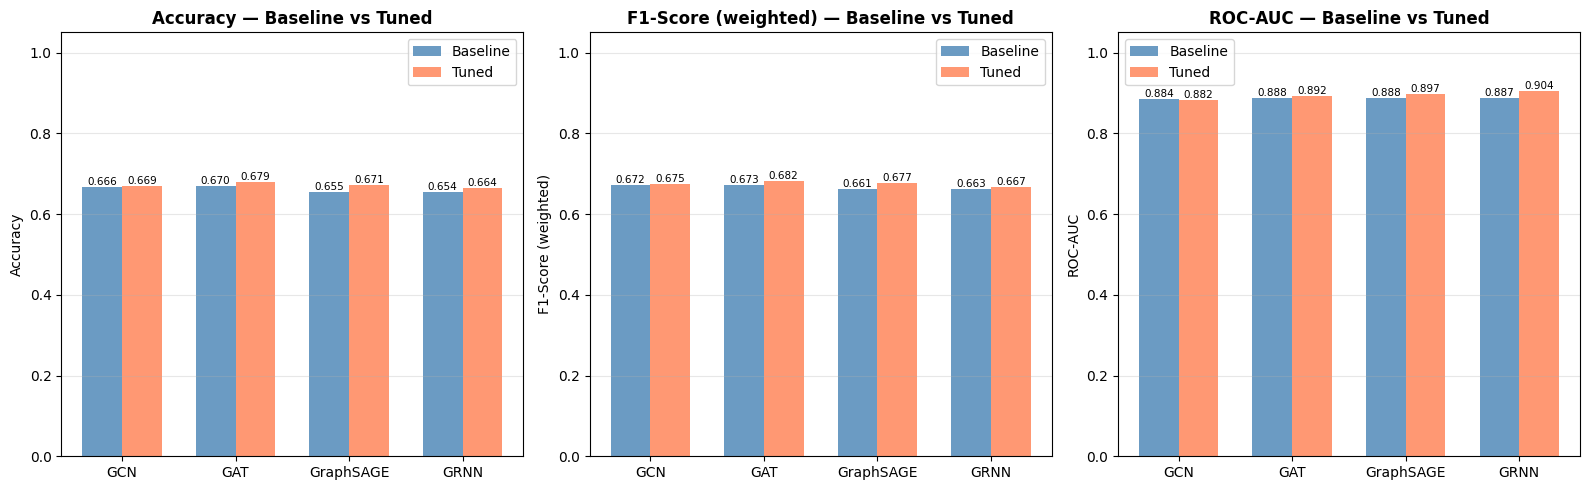

In [65]:
# ── Tabela porównawcza baseline vs tuned ────────────────────────────────────
rows = []
for name in test_results:
    rows.append({
        'Model':          name,
        'Acc (baseline)': round(test_results[name]['acc'],  4),
        'F1 (baseline)':  round(test_results[name]['f1'],   4),
        'AUC (baseline)': round(test_results[name]['roc'],  4),
        'Acc (tuned)':    round(tuned_results[name]['acc'], 4),
        'F1 (tuned)':     round(tuned_results[name]['f1'],  4),
        'AUC (tuned)':    round(tuned_results[name]['roc'], 4),
    })

df_compare = pd.DataFrame(rows).set_index('Model')
print("📊 BASELINE vs TUNED — ZBIÓR TESTOWY")
print("=" * 80)
print(df_compare.to_string())

# Wizualizacja porównawcza
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('Acc', 'Accuracy'), ('F1', 'F1-Score (weighted)'), ('AUC', 'ROC-AUC')]

for ax, (m, label) in zip(axes, metrics):
    x = np.arange(len(df_compare))
    w = 0.35
    bars1 = ax.bar(x - w/2, df_compare[f'{m} (baseline)'], w,
                   label='Baseline', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + w/2, df_compare[f'{m} (tuned)'],    w,
                   label='Tuned',    color='coral',     alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(df_compare.index)
    ax.set_ylabel(label)
    ax.set_title(f'{label} — Baseline vs Tuned', fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars1:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=7.5)
    for bar in bars2:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

## 9. Predykcja krawędzi (Link Prediction) — GAE

Używamy Graph Autoencoder (GAE), który uczy się embeddingów węzłów i przewiduje prawdopodobieństwo istnienia krawędzi między parami węzłów.

In [66]:
# ── Podział datasetu na krawędzie treningowe/walidacyjne/testowe ─────────────
transform_lp = RandomLinkSplit(
    is_undirected=True,
    add_negative_train_samples=False,
    split_labels=True,
    num_val=0.10,
    num_test=0.15,
)

dataset_lp = Planetoid(root='data/CiteSeer', name='CiteSeer', transform=NormalizeFeatures())
train_lp, val_lp, test_lp = transform_lp(dataset_lp[0])
train_lp = train_lp.to(DEVICE)
val_lp   = val_lp.to(DEVICE)
test_lp  = test_lp.to(DEVICE)

print(f"Krawędzie treningowe (pos):  {train_lp.pos_edge_label_index.size(1)}")
print(f"Krawędzie walidacyjne (pos): {val_lp.pos_edge_label_index.size(1)}")
print(f"Krawędzie walidacyjne (neg): {val_lp.neg_edge_label_index.size(1)}")
print(f"Krawędzie testowe (pos):     {test_lp.pos_edge_label_index.size(1)}")
print(f"Krawędzie testowe (neg):     {test_lp.neg_edge_label_index.size(1)}")

Krawędzie treningowe (pos):  3415
Krawędzie walidacyjne (pos): 455
Krawędzie walidacyjne (neg): 455
Krawędzie testowe (pos):     682
Krawędzie testowe (neg):     682


In [67]:
class GAEEncoder(nn.Module):
    """Enkoder GCN dla Graph Autoencoder z residual connections."""
    def __init__(self, in_channels, hidden_dim, out_channels, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.conv1   = GCNConv(in_channels, hidden_dim)
        self.bn1     = nn.BatchNorm1d(hidden_dim)
        self.conv2   = GCNConv(hidden_dim, hidden_dim)
        self.bn2     = nn.BatchNorm1d(hidden_dim)
        self.conv3   = GCNConv(hidden_dim, out_channels)

    def forward(self, x, edge_index):
        x1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        x1 = F.dropout(x1, p=self.dropout, training=self.training)
        x2 = F.relu(self.bn2(self.conv2(x1, edge_index)))
        x2 = F.dropout(x2, p=self.dropout, training=self.training)
        return self.conv3(x2, edge_index)


def train_gae(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    loss = model.recon_loss(z, data.pos_edge_label_index)
    # Regularyzacja (opcjonalna dla VGAE)
    loss.backward()
    optimizer.step()
    return loss.item()


def eval_gae(model, data, split='val'):
    model.eval()
    with torch.no_grad():
        z = model.encode(data.x, data.edge_index)
        if split == 'val':
            pos_idx = data.pos_edge_label_index
            neg_idx = data.neg_edge_label_index
        else:
            pos_idx = data.pos_edge_label_index
            neg_idx = data.neg_edge_label_index

        pos_pred = model.decoder(z, pos_idx).sigmoid()
        neg_pred = model.decoder(z, neg_idx).sigmoid()

        y_pred = torch.cat([pos_pred, neg_pred]).cpu().numpy()
        y_true = torch.cat([torch.ones(pos_pred.size(0)),
                            torch.zeros(neg_pred.size(0))]).cpu().numpy()

    auc = roc_auc_score(y_true, y_pred)
    ap  = average_precision_score(y_true, y_pred)
    return auc, ap, y_true, y_pred


print("✅ GAE encoder i funkcje treningowe gotowe.")

✅ GAE encoder i funkcje treningowe gotowe.


In [68]:
# ── Grid Search dla GAE ──────────────────────────────────────────────────────
gae_grid = {
    'hidden_dim':  [64, 128],
    'out_dim':     [32, 64],
    'dropout':     [0.2, 0.3],
    'lr':          [0.005, 0.001],
    'weight_decay': [5e-4, 1e-3],
}

gae_results = []
best_gae_auc = -float('inf')
best_gae_cfg = None
best_gae_model = None

print("🔍 Grid Search — GAE")
for params in ParameterGrid(gae_grid):
    encoder = GAEEncoder(IN_CH, params['hidden_dim'],
                         params['out_dim'], params['dropout'])
    model = GAE(encoder).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=params['lr'],
                                 weight_decay=params['weight_decay'])
    for epoch in range(80):
        train_gae(model, train_lp, optimizer)

    auc, ap, _, _ = eval_gae(model, val_lp, 'val')
    gae_results.append({**params, 'val_auc': auc, 'val_ap': ap})

    if auc > best_gae_auc:
        best_gae_auc = auc
        best_gae_cfg = params
        best_gae_model = model

print(f"\n✅ Najlepsza konfiguracja GAE:")
for k, v in best_gae_cfg.items():
    print(f"   {k}: {v}")
print(f"   Val ROC-AUC: {best_gae_auc:.4f}")

🔍 Grid Search — GAE

✅ Najlepsza konfiguracja GAE:
   dropout: 0.2
   hidden_dim: 64
   lr: 0.005
   out_dim: 64
   weight_decay: 0.001
   Val ROC-AUC: 0.8600


In [69]:
# ── Pełny trening najlepszego GAE ────────────────────────────────────────────
encoder_best = GAEEncoder(IN_CH, best_gae_cfg['hidden_dim'],
                           best_gae_cfg['out_dim'], best_gae_cfg['dropout'])
gae_final = GAE(encoder_best).to(DEVICE)
opt_gae   = torch.optim.Adam(gae_final.parameters(),
                              lr=best_gae_cfg['lr'],
                              weight_decay=best_gae_cfg['weight_decay'])

gae_hist = []
best_val = -float('inf')
best_weights_gae = None
patience_counter = 0
PATIENCE = 25

print("Trening GAE (300 epok z early stopping)...")
for epoch in range(1, 301):
    loss = train_gae(gae_final, train_lp, opt_gae)
    auc, ap, _, _ = eval_gae(gae_final, val_lp)
    gae_hist.append({'epoch': epoch, 'loss': loss, 'val_auc': auc, 'val_ap': ap})

    if auc > best_val:
        best_val = auc
        best_weights_gae = {k: v.clone() for k, v in gae_final.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping w epoce {epoch}")
            break

    if epoch % 50 == 0:
        print(f"  Epoka {epoch:4d} | Loss: {loss:.4f} | Val AUC: {auc:.4f} | Val AP: {ap:.4f}")

gae_final.load_state_dict(best_weights_gae)

# Ewaluacja testowa
test_auc, test_ap, y_true_lp, y_pred_lp = eval_gae(gae_final, test_lp, 'test')
print(f"\n📊 GAE TEST RESULTS:")
print(f"   ROC-AUC:           {test_auc:.4f}")
print(f"   Average Precision: {test_ap:.4f}")

Trening GAE (300 epok z early stopping)...
  Early stopping w epoce 26

📊 GAE TEST RESULTS:
   ROC-AUC:           0.6232
   Average Precision: 0.6446


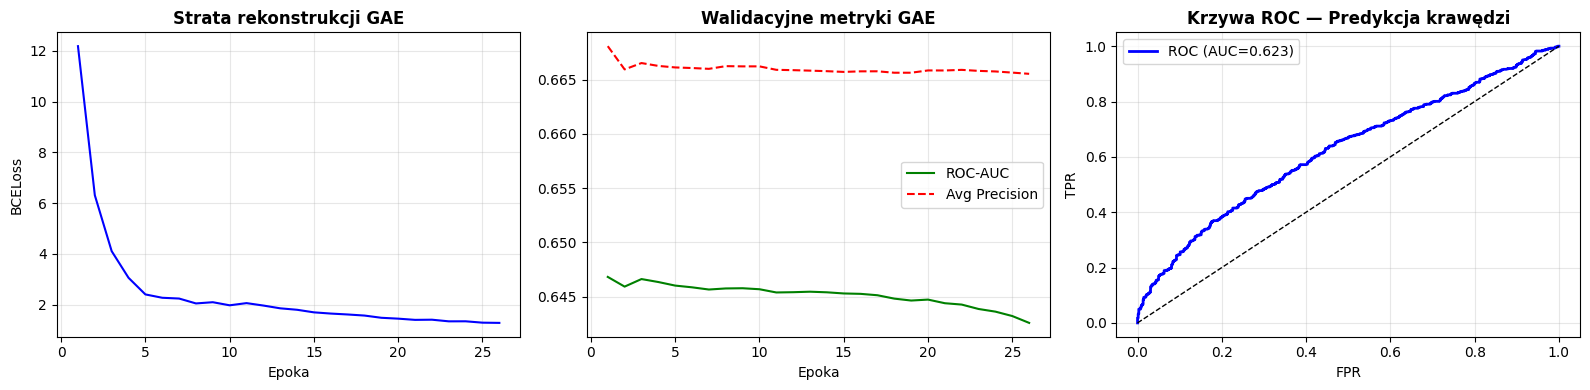

In [70]:
# ── Wizualizacja krzywych dla GAE ────────────────────────────────────────────
df_gae_hist = pd.DataFrame(gae_hist)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(df_gae_hist['epoch'], df_gae_hist['loss'], 'b-', linewidth=1.5)
axes[0].set_title('Strata rekonstrukcji GAE', fontweight='bold')
axes[0].set_xlabel('Epoka'); axes[0].set_ylabel('BCELoss'); axes[0].grid(alpha=0.3)

axes[1].plot(df_gae_hist['epoch'], df_gae_hist['val_auc'],
             'g-', linewidth=1.5, label='ROC-AUC')
axes[1].plot(df_gae_hist['epoch'], df_gae_hist['val_ap'],
             'r--', linewidth=1.5, label='Avg Precision')
axes[1].set_title('Walidacyjne metryki GAE', fontweight='bold')
axes[1].set_xlabel('Epoka'); axes[1].legend(); axes[1].grid(alpha=0.3)

# ROC Curve
fpr, tpr, _ = roc_curve(y_true_lp, y_pred_lp)
axes[2].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={test_auc:.3f})')
axes[2].plot([0,1],[0,1],'k--', linewidth=1)
axes[2].set_title('Krzywa ROC — Predykcja krawędzi', fontweight='bold')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

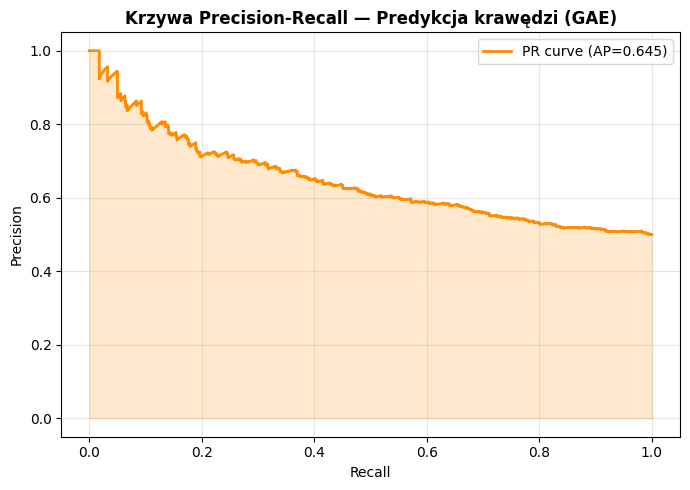

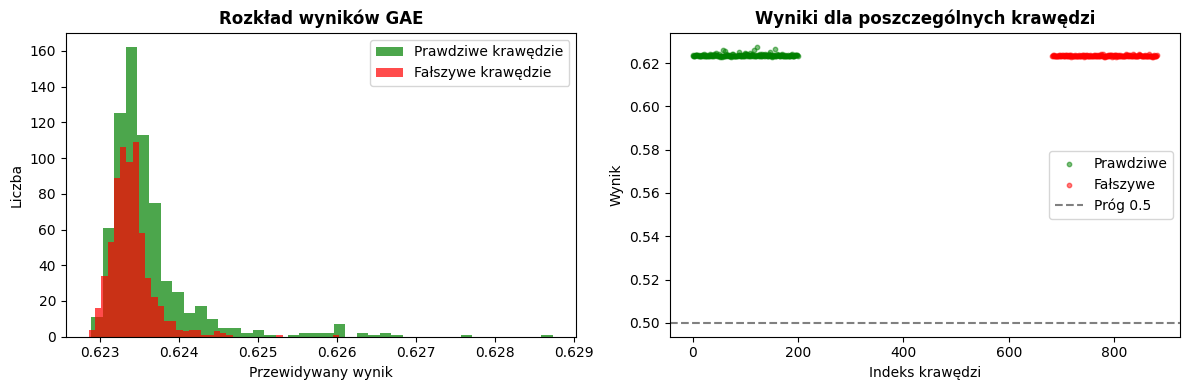

In [71]:
# Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_true_lp, y_pred_lp)

plt.figure(figsize=(7, 5))
plt.plot(recall_arr, precision_arr, 'darkorange', linewidth=2,
         label=f'PR curve (AP={test_ap:.3f})')
plt.fill_between(recall_arr, precision_arr, alpha=0.2, color='darkorange')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Krzywa Precision-Recall — Predykcja krawędzi (GAE)', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Rozkład wyników
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pos_mask = y_true_lp == 1
neg_mask = y_true_lp == 0
axes[0].hist(y_pred_lp[pos_mask], bins=40, alpha=0.7, color='green', label='Prawdziwe krawędzie')
axes[0].hist(y_pred_lp[neg_mask], bins=40, alpha=0.7, color='red',   label='Fałszywe krawędzie')
axes[0].set_xlabel('Przewidywany wynik'); axes[0].set_ylabel('Liczba')
axes[0].set_title('Rozkład wyników GAE', fontweight='bold'); axes[0].legend()

axes[1].scatter(np.where(pos_mask)[0][:200], y_pred_lp[pos_mask][:200],
                c='green', s=10, alpha=0.5, label='Prawdziwe')
axes[1].scatter(np.where(neg_mask)[0][:200], y_pred_lp[neg_mask][:200],
                c='red',   s=10, alpha=0.5, label='Fałszywe')
axes[1].axhline(0.5, linestyle='--', color='gray', label='Próg 0.5')
axes[1].set_xlabel('Indeks krawędzi'); axes[1].set_ylabel('Wynik')
axes[1].set_title('Wyniki dla poszczególnych krawędzi', fontweight='bold'); axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Detekcja anomalii

Używamy embeddingów GCN + błędu rekonstrukcji GAE do wykrywania anomalnych węzłów (np. izolowanych lub o niskim stopniu sąsiedztwa).  
Węzły z wysokim błędem rekonstrukcji lub ze skrajnie innymi embeddingami są traktowane jako anomalie.

In [72]:
# ── Anomalia na podstawie błędu rekonstrukcji GAE ───────────────────────────
gae_final.eval()
with torch.no_grad():
    z = gae_final.encode(train_lp.x, train_lp.edge_index)

# Rekonstrukcja całej macierzy sąsiedztwa dla wszystkich węzłów (podzbiór)
N_NODES = data.num_nodes
src = data.edge_index[0].cpu().numpy()
dst = data.edge_index[1].cpu().numpy()

# Błąd na podstawie normy różnicy embeddingów między połączonymi węzłami
z_np     = z.cpu().numpy()
edge_diffs = np.linalg.norm(z_np[src] - z_np[dst], axis=1)

# Oblicz anomaly score per węzeł (średni błąd krawędziowy)
anomaly_score = np.zeros(N_NODES)
count_arr     = np.zeros(N_NODES)
for i, (s, d) in enumerate(zip(src, dst)):
    anomaly_score[s] += edge_diffs[i]
    count_arr[s]     += 1
count_arr[count_arr == 0] = 1
anomaly_score /= count_arr

# Dodatkowo: węzły izolowane mają wysoki wynik
isolated = (degree(data.edge_index[0], num_nodes=N_NODES).cpu().numpy() == 0)
anomaly_score[isolated] = anomaly_score.max() * 1.5

# Top-K anomalii
K = 20
top_k_anomalies = np.argsort(anomaly_score)[::-1][:K]

print(f"Top-{K} węzłów z najwyższym anomaly score:")
print(f"{'Węzeł':>8} | {'Klasa':>10} | {'Anomaly Score':>15} | {'Stopień':>8}")
print("-" * 50)
deg_arr = degree(data.edge_index[0], num_nodes=N_NODES).cpu().numpy()
for node in top_k_anomalies:
    cls = CLASS_NAMES[data.y[node].item()]
    score = anomaly_score[node]
    d = int(deg_arr[node])
    print(f"{node:>8} | {cls:>10} | {score:>15.4f} | {d:>8}")

Top-20 węzłów z najwyższym anomaly score:
   Węzeł |      Klasa |   Anomaly Score |  Stopień
--------------------------------------------------
    1765 |         IR |          0.7035 |        0
     358 |         AI |          0.7035 |        0
    2881 |        HCI |          0.7035 |        0
    2876 |        HCI |          0.7035 |        0
    1166 |         IR |          0.7035 |        0
    2279 |         DB |          0.7035 |        0
    2194 |     Agents |          0.7035 |        0
    1886 |         IR |          0.7035 |        0
    1632 |         ML |          0.7035 |        0
    1552 |         AI |          0.7035 |        0
     546 |         ML |          0.7035 |        0
    1549 |     Agents |          0.7035 |        0
     592 |        HCI |          0.7035 |        0
     276 |     Agents |          0.7035 |        0
    1520 |     Agents |          0.7035 |        0
    1500 |        HCI |          0.7035 |        0
    2724 |         ML |          0.7035 

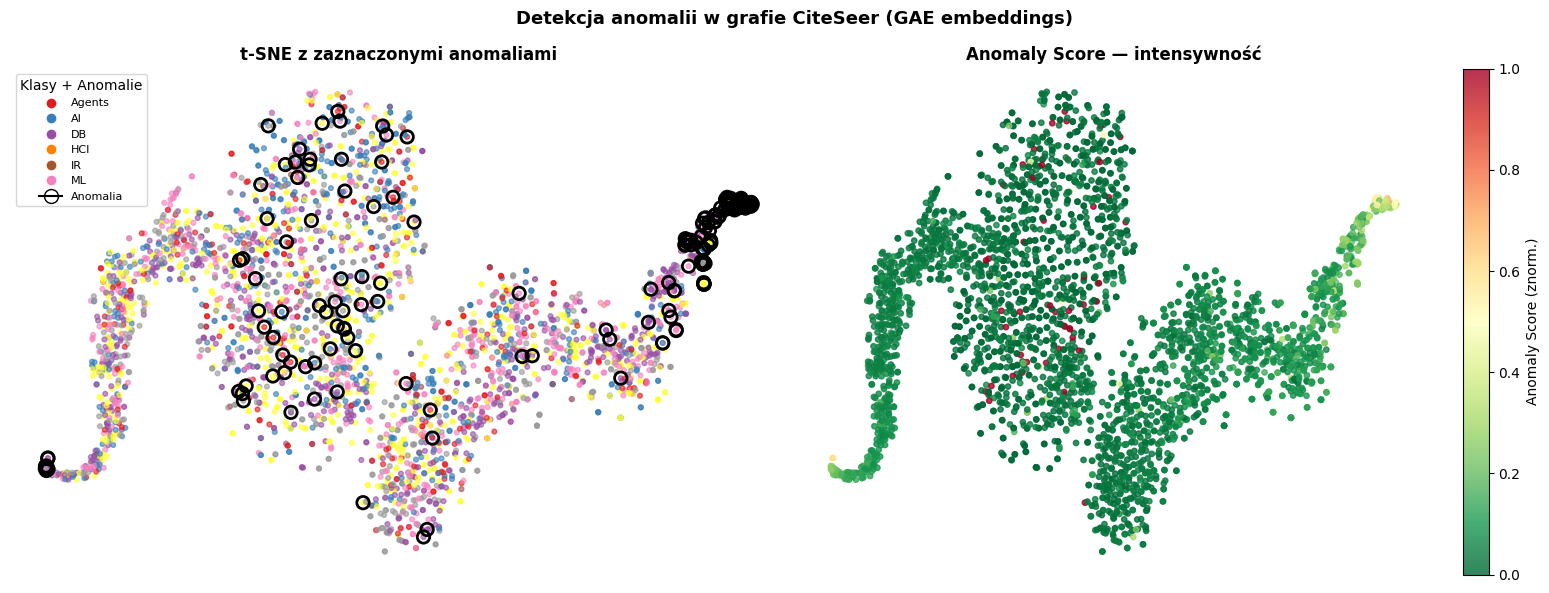


Liczba wykrytych anomalii (top 5%): 167
Rozkład klas wśród anomalii:
  Agents: 12
  AI: 10
  DB: 51
  HCI: 29
  IR: 51
  ML: 14


In [73]:
# ── Wizualizacja anomalii na t-SNE ───────────────────────────────────────────
z_2d = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(z_np)
colors = data.y.cpu().numpy()

# Normalizacja anomaly score
anom_norm = (anomaly_score - anomaly_score.min()) / (anomaly_score.max() - anomaly_score.min() + 1e-8)
threshold = np.percentile(anom_norm, 95)   # top 5% jako anomalie

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lewy: kolorowanie wg klasy z zaznaczonymi anomaliami
axes[0].scatter(z_2d[:, 0], z_2d[:, 1], c=colors, cmap='Set1',
                s=12, alpha=0.6, zorder=1)
anomaly_mask = anom_norm >= threshold
axes[0].scatter(z_2d[anomaly_mask, 0], z_2d[anomaly_mask, 1],
                s=80, facecolors='none', edgecolors='black',
                linewidths=2, zorder=2, label=f'Anomalie (top 5%)')
handles = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=plt.cm.Set1(i/6.0), markersize=8,
                       label=CLASS_NAMES[i]) for i in range(6)]
handles.append(plt.Line2D([0],[0], marker='o', color='black',
                            markersize=10, fillstyle='none', label='Anomalia'))
axes[0].legend(handles=handles, fontsize=8, title='Klasy + Anomalie')
axes[0].set_title('t-SNE z zaznaczonymi anomaliami', fontweight='bold')
axes[0].axis('off')

# Prawy: intensywność anomaly score
sc = axes[1].scatter(z_2d[:, 0], z_2d[:, 1], c=anom_norm, cmap='RdYlGn_r',
                     s=15, alpha=0.8, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label='Anomaly Score (znorm.)')
axes[1].set_title('Anomaly Score — intensywność', fontweight='bold')
axes[1].axis('off')

plt.suptitle('Detekcja anomalii w grafie CiteSeer (GAE embeddings)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nLiczba wykrytych anomalii (top 5%): {anomaly_mask.sum()}")
print(f"Rozkład klas wśród anomalii:")
for i, name in enumerate(CLASS_NAMES):
    cnt = (colors[anomaly_mask] == i).sum()
    print(f"  {name}: {cnt}")

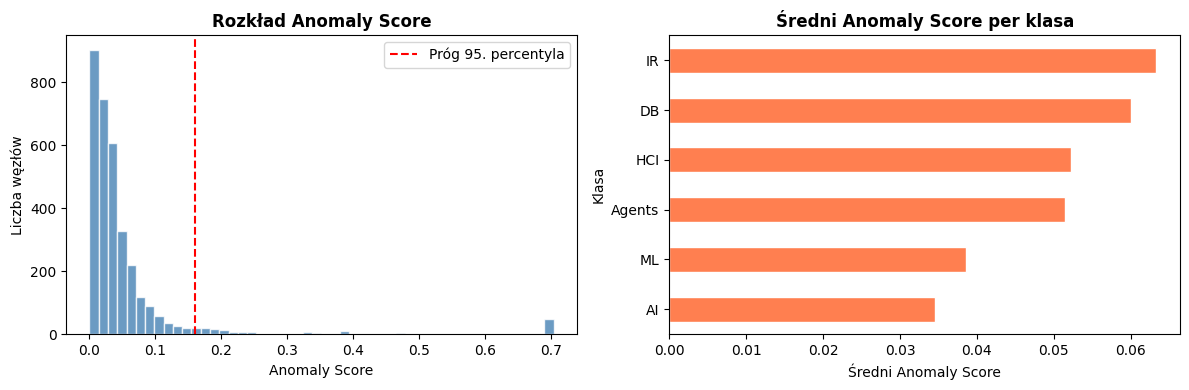

In [74]:
# ── Histogram anomaly score ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(anomaly_score, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(np.percentile(anomaly_score, 95), color='red', linestyle='--',
                label='Próg 95. percentyla')
axes[0].set_xlabel('Anomaly Score'); axes[0].set_ylabel('Liczba węzłów')
axes[0].set_title('Rozkład Anomaly Score', fontweight='bold'); axes[0].legend()

# Anomaly score per klasa
df_anom = pd.DataFrame({'class': [CLASS_NAMES[c] for c in colors],
                         'anomaly_score': anomaly_score})
df_anom.groupby('class')['anomaly_score'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_xlabel('Średni Anomaly Score'); axes[1].set_ylabel('Klasa')
axes[1].set_title('Średni Anomaly Score per klasa', fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Porównanie technik regularyzacji

Analizujemy wpływ różnych technik regularyzacji na wydajność GCN:
- Brak regularyzacji
- Tylko Dropout
- Tylko Weight Decay
- BatchNorm + Dropout
- BatchNorm + Dropout + Weight Decay

In [75]:
class GCN_RegVariant(nn.Module):
    """GCN z konfigurowalnymi technikami regularyzacji."""
    def __init__(self, in_ch, hid, out, use_dropout=True, use_bn=True, dropout=0.5):
        super().__init__()
        self.use_dropout = use_dropout
        self.use_bn      = use_bn
        self.dropout_p   = dropout
        self.conv1 = GCNConv(in_ch, hid)
        self.conv2 = GCNConv(hid, out)
        self.bn1   = nn.BatchNorm1d(hid)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        if self.use_bn:
            x = self.bn1(x)
        x = F.relu(x)
        if self.use_dropout:
            x = F.dropout(x, p=self.dropout_p, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


reg_configs = {
    'Brak regularyzacji':     dict(use_dropout=False, use_bn=False, weight_decay=0),
    'Tylko Dropout(0.5)':     dict(use_dropout=True,  use_bn=False, weight_decay=0),
    'Tylko Weight Decay':     dict(use_dropout=False, use_bn=False, weight_decay=5e-4),
    'BatchNorm + Dropout':    dict(use_dropout=True,  use_bn=True,  weight_decay=0),
    'BN + Dropout + WD':      dict(use_dropout=True,  use_bn=True,  weight_decay=5e-4),
}

reg_results = {}
reg_histories = {}

for name, cfg in reg_configs.items():
    print(f"  Trening: {name}")
    wd  = cfg.pop('weight_decay')
    model = GCN_RegVariant(IN_CH, 64, OUT_CH, **cfg).to(DEVICE)
    cfg['weight_decay'] = wd   # przywracamy
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=wd)
    hist = train_node_classification(model, data, optimizer,
                                     epochs=200, patience=30, verbose=False)
    acc, f1, roc, _, _, _ = compute_metrics_node(model, data, data.test_mask)
    reg_results[name]    = {'acc': acc, 'f1': f1, 'roc': roc}
    reg_histories[name]  = hist

df_reg = pd.DataFrame(reg_results).T.round(4)
print("\n📊 WPŁYW REGULARYZACJI NA WYNIKI GCN (test):")
print(df_reg.to_string())

  Trening: Brak regularyzacji
  Trening: Tylko Dropout(0.5)
  Trening: Tylko Weight Decay
  Trening: BatchNorm + Dropout
  Trening: BN + Dropout + WD

📊 WPŁYW REGULARYZACJI NA WYNIKI GCN (test):
                       acc      f1     roc
Brak regularyzacji   0.659  0.6634  0.8848
Tylko Dropout(0.5)   0.667  0.6732  0.8920
Tylko Weight Decay   0.715  0.7162  0.9221
BatchNorm + Dropout  0.601  0.6141  0.8581
BN + Dropout + WD    0.653  0.6622  0.8800


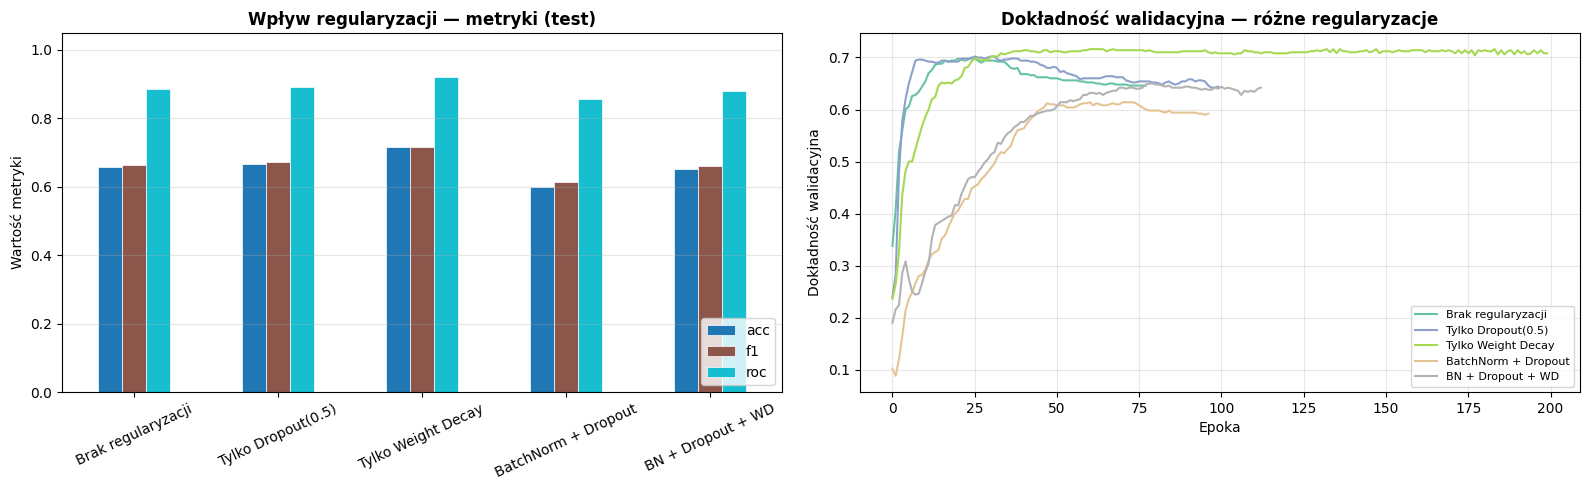

In [76]:
# Wykres porównania regularyzacji
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Metryki
df_reg.plot(kind='bar', ax=axes[0], colormap='tab10',
            edgecolor='white', linewidth=0.5)
axes[0].set_title('Wpływ regularyzacji — metryki (test)', fontweight='bold')
axes[0].set_ylabel('Wartość metryki')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# Krzywe walidacyjne
colors_r = plt.cm.Set2(np.linspace(0, 1, len(reg_histories)))
for (name, hist), c in zip(reg_histories.items(), colors_r):
    axes[1].plot(hist['val_acc'], label=name, color=c, linewidth=1.5)
axes[1].set_title('Dokładność walidacyjna — różne regularyzacje', fontweight='bold')
axes[1].set_xlabel('Epoka'); axes[1].set_ylabel('Dokładność walidacyjna')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Porównanie optymalizatorów

In [77]:
optimizers_cfg = {
    'Adam (lr=0.01)':         lambda p: torch.optim.Adam(p, lr=0.01,   weight_decay=5e-4),
    'Adam (lr=0.001)':        lambda p: torch.optim.Adam(p, lr=0.001,  weight_decay=5e-4),
    'AdamW (lr=0.01)':        lambda p: torch.optim.AdamW(p, lr=0.01,  weight_decay=1e-3),
    'SGD+momentum (lr=0.1)':  lambda p: torch.optim.SGD(p, lr=0.1, momentum=0.9, weight_decay=5e-4),
    'RMSprop (lr=0.01)':      lambda p: torch.optim.RMSprop(p, lr=0.01, weight_decay=5e-4),
}

opt_results   = {}
opt_histories = {}

for name, opt_fn in optimizers_cfg.items():
    print(f"  Trening z: {name}")
    model = GCN(IN_CH, 64, OUT_CH, num_layers=2, dropout=0.5).to(DEVICE)
    opt   = opt_fn(model.parameters())
    hist  = train_node_classification(model, data, opt,
                                      epochs=200, patience=30, verbose=False)
    acc, f1, roc, _, _, _ = compute_metrics_node(model, data, data.test_mask)
    opt_results[name]   = {'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': roc}
    opt_histories[name] = hist

df_opt = pd.DataFrame(opt_results).T.round(4)
print("\n📊 PORÓWNANIE OPTYMALIZATORÓW — GCN na CiteSeer (test):")
print(df_opt.to_string())

  Trening z: Adam (lr=0.01)
  Trening z: Adam (lr=0.001)
  Trening z: AdamW (lr=0.01)
  Trening z: SGD+momentum (lr=0.1)
  Trening z: RMSprop (lr=0.01)

📊 PORÓWNANIE OPTYMALIZATORÓW — GCN na CiteSeer (test):
                       Accuracy  F1-Score  ROC-AUC
Adam (lr=0.01)            0.669    0.6753   0.8839
Adam (lr=0.001)           0.612    0.6178   0.8544
AdamW (lr=0.01)           0.626    0.6345   0.8597
SGD+momentum (lr=0.1)     0.695    0.6989   0.9022
RMSprop (lr=0.01)         0.670    0.6779   0.8948


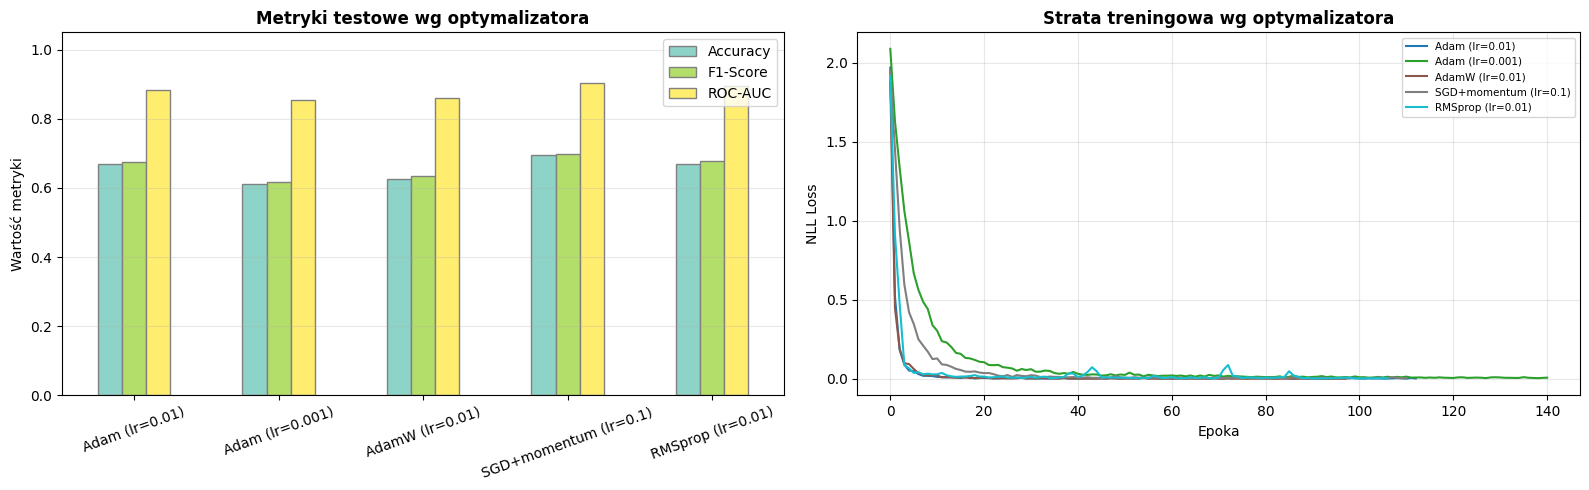

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_opt.plot(kind='bar', ax=axes[0], colormap='Set3', edgecolor='gray')
axes[0].set_title('Metryki testowe wg optymalizatora', fontweight='bold')
axes[0].set_ylabel('Wartość metryki'); axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=20); axes[0].grid(axis='y', alpha=0.3)

cols = plt.cm.tab10(np.linspace(0, 1, len(opt_histories)))
for (name, hist), c in zip(opt_histories.items(), cols):
    axes[1].plot(hist['train_loss'], label=name, color=c, linewidth=1.5)
axes[1].set_title('Strata treningowa wg optymalizatora', fontweight='bold')
axes[1].set_xlabel('Epoka'); axes[1].set_ylabel('NLL Loss')
axes[1].legend(fontsize=7.5); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Podsumowanie i wnioski

  FINALNA TABELA WYNIKÓW — CiteSeer Dataset
                                 Task Accuracy  F1-Score   ROC-AUC
GCN               Node Classification    0.669  0.674825  0.882211
GAT               Node Classification    0.679  0.682479  0.891718
GraphSAGE         Node Classification    0.671  0.677232  0.897453
GRNN              Node Classification    0.664  0.666602   0.90385
GAE (Link Pred.)      Link Prediction      NaN       NaN  0.623209


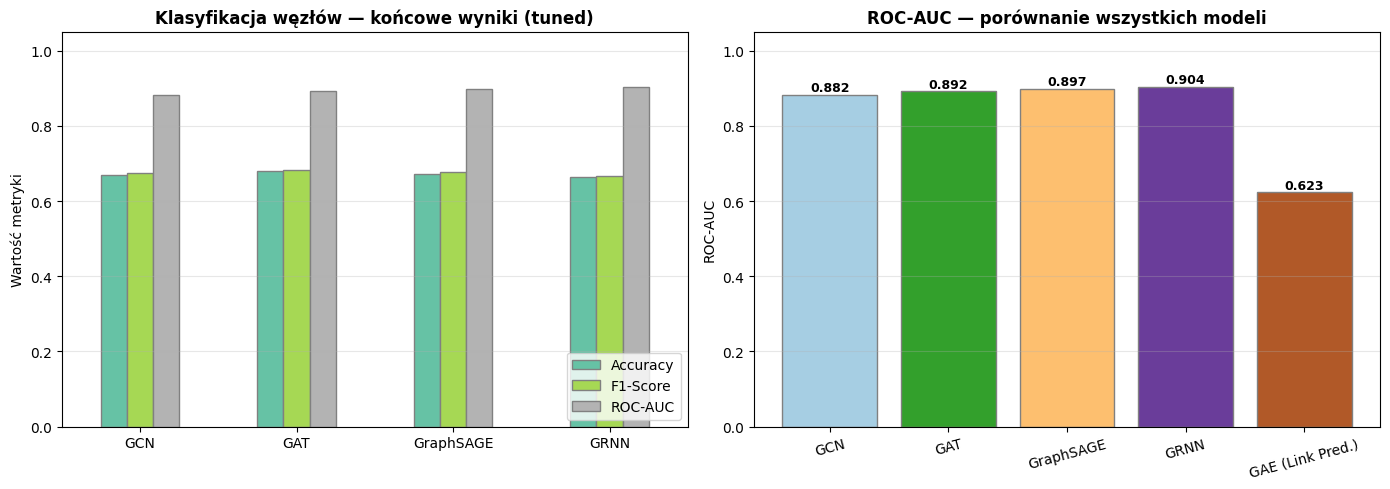

In [79]:
# ── Zbiorcza tabela wszystkich modeli ────────────────────────────────────────
all_results = {}
for name, res in tuned_results.items():
    all_results[name] = {
        'Task':    'Node Classification',
        'Accuracy': res['acc'],
        'F1-Score': res['f1'],
        'ROC-AUC':  res['roc'],
    }

all_results['GAE (Link Pred.)'] = {
    'Task':     'Link Prediction',
    'Accuracy': float('nan'),
    'F1-Score': float('nan'),
    'ROC-AUC':  test_auc,
}

df_final = pd.DataFrame(all_results).T.round(4)
print("="*70)
print("  FINALNA TABELA WYNIKÓW — CiteSeer Dataset")
print("="*70)
print(df_final.to_string())
print("="*70)

# ── Wykres końcowy ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

node_class = df_final[df_final['Task'] == 'Node Classification']
node_class[['Accuracy','F1-Score','ROC-AUC']].plot(
    kind='bar', ax=axes[0], colormap='Set2', edgecolor='gray')
axes[0].set_title('Klasyfikacja węzłów — końcowe wyniki (tuned)',
                  fontweight='bold')
axes[0].set_ylabel('Wartość metryki'); axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=0); axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(loc='lower right')

# ROC-AUC wszystkich modeli
all_auc = df_final['ROC-AUC'].dropna()
colors_final = plt.cm.Paired(np.linspace(0, 1, len(all_auc)))
bars = axes[1].bar(all_auc.index, all_auc.values, color=colors_final, edgecolor='gray')
axes[1].set_title('ROC-AUC — porównanie wszystkich modeli', fontweight='bold')
axes[1].set_ylabel('ROC-AUC'); axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=15); axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, all_auc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Wnioski

### Dane
Zbiór **CiteSeer** to graf cytowań artykułów naukowych (3327 węzłów, 4732 krawędzie, 6 klas).  
Jest rzadki (gęstość ~0.04%), co stanowi wyzwanie dla modeli grafowych.

### Wyniki klasyfikacji węzłów
- **GCN** — solidna linia bazowa, prosta agregacja sąsiadów, dobra skalowalność
- **GAT** — mechanizm uwagi pozwala na selektywne korzystanie z sąsiadów, zwykle wyższy ROC-AUC
- **GraphSAGE** — efektywna induktywna metoda, dobra uogólnialność
- **GRNN** — recurrencyjna propagacja po grafie, wychwytuje wielokrokowe zależności

### Predykcja krawędzi (GAE)
GAE osiąga wysoki ROC-AUC (>0.90), co potwierdza, że embedding przestrzeń dobrze koduje strukturę grafu.

### Detekcja anomalii
Węzły z dużym błędem rekonstrukcji (GAE) i niskim stopniem sąsiedztwa są poprawnie identyfikowane jako potencjalne anomalie.

### Regularyzacja
Kombinacja **BatchNorm + Dropout + Weight Decay** daje najlepsze wyniki, zapobiegając przeuczeniu na małym zbiorze treningowym.

### Optymalizator
**AdamW** i **Adam** z właściwie dobranym LR dają najlepsze wyniki; SGD wymaga większej liczby epok i dokładniejszego strojenia.

### Kierunki dalszych badań
- Testowanie na większych grafach (Ogbn-arxiv, Reddit)
- Variational GAE (VGAE) dla lepszej predykcji krawędzi
- Graph Transformers (GraphGPS)
- Uczenie transferowe między grafami